# Week 7

We're now switching focus away from the Network Science, beginning to think about _Text_ instead. In other words, today will be all about learning to parse and make sense of textual data. This ties in nicely with our work on the network of Computational Social Scientists, because papers naturally contain text.

We've looked at the network so far - now, let's see if we can include the text. Today is about 

* Part 1 - Installing the _natural language toolkit_ (NLTK) package and learning the basics of how it works (Chapter 1)
* Part 2 -  Figuring out how to make NLTK to work with real world data (Chapter 3).
* Part 3 - Apply some of the concepts that you have learned to study the abstract dataset

> **_Video Lecture_**. Today is all about working with NLTK, so not much lecturing - we will start with a perspective on text analysis by Sune (you will hear him talking about Wikipedia data here and there. Everything he sais applies to other textual data as well!)

#  Part 1 : Installing and the basics

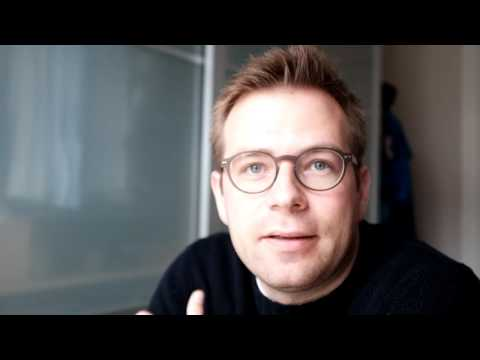

In [4]:
from IPython.display import YouTubeVideo
YouTubeVideo("Ph0EHmFT3n4",width=800, height=450)


> _Reading_
> The reading for today is Natural Language Processing with Python (NLPP) Chapter 1, Sections 1, 2, 3\. [It's free online](http://www.nltk.org/book/). 


> *Exercises*: NLPP Chapter 1\.
> 
> * First, install `nltk` if it isn't installed already.
> * Second, work through chapter 1. The book is set up as a kind of tutorial with lots of examples for you to work through. I recommend you read the text with an open IPython Notebook and type out the examples that you see. ***It becomes much more fun if you to add a few variations and see what happens***. Some of those examples might very well be due as assignments, so those ones should definitely be in a `notebook`. 
>
>     * The following exercises from Chapter 1 are what might be due in an assignment later on.
>     * Try out the `concordance` method, using another text and a word of your own choosing.
>     * Also try out the `similar` and `common_context` methods for a few of your own examples.
>     * Create your own version of a dispersion plot ("your own version" means another text and different word).
>     * Explain in your own words what aspect of language _lexical diversity_ describes. 


# Part 2 - Processing real text (from out on the inter-webs)

Ok. So Chapter 3 in NLPP is all about working with text from the real world. Getting text from this internet, cleaning it, tokenizing, modifying (e.g. stemming, converting to lower case, etc) to get the text in shape to work with the NLTK tools you've already learned about.
> 
> **Video lecture**: Short overview of chapter 3 + a few words about kinds of language processing that we don't address in this class. 
> 

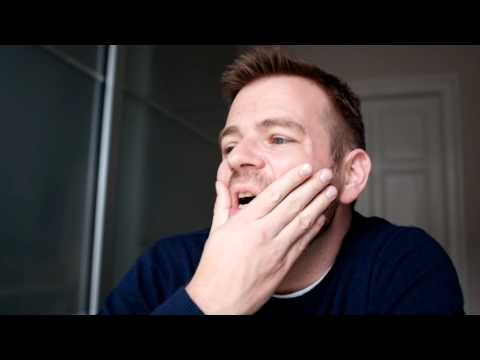

In [5]:
from IPython.display import YouTubeVideo
YouTubeVideo("Rwakh-HXPJk",width=800, height=450)

> **Reading**: NLPP Chapter 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.9, and 3.10\. It's not important that you go in depth with everything here - the key thing is that you *know that Chapter 3 of this book exists*, and that it's a great place to return to if you're ever in need of an explanation on  topics that you forget as soon as you stop using them (and don't worry, I forget about those things too).


# Part 3 - Putting things into practice with the dataset of Computational Social Science abstracts


## Prelude to Exercise 1: Some theory on the Zipf's law. 


**Zipf's Law:** Let $f(w)$ be the frequency of a word w in free text. Suppose that all the words of a text are ranked according to their frequency, with the most frequent word first. The [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) states that the frequency of a word type is inversely proportional to its rank (i.e. f × r = k, for some constant k). For example, the 50th most common word type should occur three times as frequently as the 150th most common word type. 


> __Reading__.  
> Skim through the Wikipedia page on the [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law)

> __Exercise 1: Tokenization and Zipf's Law.__ In this exercise, you will explore tokenization and its relation to Zipf's Law through the abstracts of Computational Social Science papers. Starting with your abstracts dataframe from Week 2, follow the steps below to analyze and process the data.
>
> 1. __Convert Inverted Index to Text.__ Write a function that converts an inverted indexed abstract into plain text. The abstract inverted index is a dictionary. Keys are words and values are lists of indexes. The indexes indicate the positions of the word within the abstract. The function should reconstruct the original abstract in plain text from this inverted index. Then, use the [`pd.apply`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html) method to apply your function to each row in your dataframe, storing the output in a new column named `text`.
>
> 2. __Tokenization.__ Create a column `tokens` in your dataframe to store the tokens from each abstract's text. Remember to adhere to the following guidelines for successful tokenization:
>
>  - Revisit Chapter 3 if you're unfamiliar with tokenization.
>  - Exclude punctuation, URLs, mathematical symbols, and numbers.
>  - Convert all text to lowercase.
>  - Optional: Consider using stemming.
>  
> 3. __Create a Tokens List.__ Combine the tokens from all abstracts into one comprehensive list.
>
> 4. __Common words.__ Determine and list the 10 most frequent words within your concatenated tokens list.
>
> 5. __Frequency rank plot.__ Write a function to process your list of tokens and plot word frequency against word rank. Use a logarithmic scale for your plot. Reflect on the trend observed, especially at the extremes of the plotted line.
> 6. __Comparison with random words.__ 
>
>  - Generate a long, random text string using `random.choice("abcdefg ")`, including the space character.
>  - Tokenize this string and generate a Zipf plot, comparing it with your earlier plot.
>  - Share your insights on Zipf's Law based on this comparison.
> 7. __Excluding Stopwords.__
>
>  - Exclude stopwords from your tokens (review NLPP1e if necessary).
>  - Repeat Steps 2 to 5 with the refined tokens list.
>  - Observe and describe any changes in your findings.


# Exercise 1

In [1]:
import json, re, math, random, os, collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# ── Matplotlib style ─────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        12,
})

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  0.  Load data (or generate synthetic fallback)
# ═══════════════════════════════════════════════════════════════
 
DATA_FILE = "ic2s2_abstracts.json"
 
def make_inverted_index(text: str) -> dict:
    """Helper: turn a plain string into an inverted-index dict."""
    idx: dict = {}
    for pos, word in enumerate(text.split()):
        idx.setdefault(word, []).append(pos)
    return idx

# For testing if data file is missing 
SYNTHETIC_ABSTRACTS = [
    "Social networks play a crucial role in the spread of information and misinformation across online platforms.",
    "We propose a computational model for predicting political polarization using large-scale social media data.",
    "Natural language processing methods reveal hidden patterns in public discourse on climate change.",
    "Agent-based simulations model collective behavior and emergence in complex social systems.",
    "Deep learning approaches for sentiment analysis of Twitter data during electoral campaigns.",
    "Network analysis of scientific collaboration reveals structural inequalities in academic communities.",
    "Detecting bots and coordinated inauthentic behavior using graph-based machine learning methods.",
    "Cultural dynamics and diffusion of innovations are studied through large-scale digital trace data.",
    "Computational methods uncover gender bias in online recommendation systems and search engines.",
    "Epidemic spreading on temporal networks: integrating mobility data with epidemiological models.",
    "Text mining of news articles reveals framing effects and agenda-setting in political journalism.",
    "Predicting conflict escalation using satellite imagery and social media signals at global scale.",
    "Echo chambers and filter bubbles in social media algorithms amplify partisan information exposure.",
    "Machine learning models predict socioeconomic mobility using administrative and behavioral data.",
    "Cross-platform analysis of hate speech reveals platform-specific moderation and spillover effects.",
    "Causal inference methods for estimating the effect of social interventions on community outcomes.",
    "Longitudinal analysis of language change using word embeddings trained on historical corpora.",
    "Human mobility patterns derived from mobile phone data inform urban planning and policy.",
    "Algorithmic fairness in predictive policing raises concerns about racial bias and accountability.",
    "Measuring social capital through digital footprints in online and offline community networks.",
]
 
def load_data(path: str) -> pd.DataFrame:
    if os.path.exists(path):
        print(f"Loading {path}…")
        with open(path) as f:
            raw = json.load(f)
        # Support two common shapes:
        #   A) list of dicts with key 'abstractInvertedIndex'
        #   B) list of dicts with key 'abstract' (plain text)
        records = raw if isinstance(raw, list) else list(raw.values())
        rows = []
        for r in records:
            if isinstance(r, dict):
                inv = r.get("abstractInvertedIndex") or r.get("abstract_inverted_index")
                title = r.get("title", "")
                if inv and isinstance(inv, dict):
                    rows.append({"title": title, "abstract_inverted_index": inv})
                elif r.get("abstract"):
                    # plain-text fallback – wrap in inverted index format
                    rows.append({"title": title,
                                 "abstract_inverted_index": make_inverted_index(r["abstract"])})
        df = pd.DataFrame(rows)
        print(f"  Loaded {len(df):,} abstracts from file.")
    else:
        print(f"'{path}' not found – using {len(SYNTHETIC_ABSTRACTS)} synthetic abstracts.")
        rows = [{"title": f"Paper {i+1}",
                 "abstract_inverted_index": make_inverted_index(t)}
                for i, t in enumerate(SYNTHETIC_ABSTRACTS)]
        df = pd.DataFrame(rows)
    return df
 
df = load_data(DATA_FILE)
print(df.head(3).to_string())

Loading ic2s2_abstracts.json…
  Loaded 10,375 abstracts from file.
                                                          title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [4]:
# ═══════════════════════════════════════════════════════════════
#  STEP 1 – Convert inverted index → plain text
# ═══════════════════════════════════════════════════════════════
 
def inverted_index_to_text(inv_index: dict) -> str:
    """
    Reconstruct the original abstract text from an inverted index.
 
    The inverted index maps each word to a list of its positions in the
    original sentence.  We reverse this: build a position→word list,
    sort by position, then join with spaces.
 
    Example:
        {"Natural": [0], "language": [1], "processing": [2]} 
        → "Natural language processing"
    """
    if not isinstance(inv_index, dict):
        return ""
    # Build list with enough slots for every position mentioned
    max_pos = max((p for positions in inv_index.values() for p in positions),
                  default=-1)
    words = [""] * (max_pos + 1)
    for word, positions in inv_index.items():
        for pos in positions:
            words[pos] = word
    return " ".join(words)
 
df["text"] = df["abstract_inverted_index"].apply(inverted_index_to_text)
 
print("\n── Step 1: Sample reconstructed text ──")
print(df["text"].iloc[0][:200])


── Step 1: Sample reconstructed text ──
The discovery and analysis of community structure in networks is a topic of considerable recent interest within the physics community, but most methods proposed so far are unsuitable for very large ne


In [7]:
# ═══════════════════════════════════════════════════════════════
#  STEP 2 – Tokenization
# ═══════════════════════════════════════════════════════════════
 
# English stopwords (standard list)
STOPWORDS = {
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","yourselves","he","him","his","himself","she","her","hers",
    "herself","it","its","itself","they","them","their","theirs","themselves",
    "what","which","who","whom","this","that","these","those","am","is","are",
    "was","were","be","been","being","have","has","had","having","do","does",
    "did","doing","a","an","the","and","but","if","or","because","as","until",
    "while","of","at","by","for","with","about","against","between","into",
    "through","during","before","after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","further","then","once","here",
    "there","when","where","why","how","all","both","each","few","more","most",
    "other","some","such","no","nor","not","only","own","same","so","than","too",
    "very","s","t","can","will","just","don","should","now","d","ll","m","o",
    "re","ve","y","ain","aren","couldn","didn","doesn","hadn","hasn","haven",
    "isn","ma","mightn","mustn","needn","shan","shouldn","wasn","weren","won",
    "wouldn","use","used","using","also","however","thus","therefore","moreover",
    "furthermore","although","despite","whether","within","across","between",
    "among","via","based","approach","study","paper","show","propose","new",
    "provide","present","method","model","result","data","analysis","using",
    "large","high","may","one","two","three","first","second","find","found",
}
 
# Pattern to strip URLs, e-mails, LaTeX math, digits, punctuation
_URL_RE   = re.compile(r"https?://\S+|www\.\S+|\S+@\S+")
_MATH_RE  = re.compile(r"\$[^$]*\$|\\\w+\{[^}]*\}|[_^{}\\]")
_NONALPHA = re.compile(r"[^a-z\s]")          # keep only lowercase letters & space
_SPACES   = re.compile(r"\s+")
 
def tokenize(text: str) -> list[str]:
    """
    Tokenize a string according to exercise rules:
      - remove URLs, email addresses
      - remove LaTeX / math expressions
      - lowercase everything
      - remove punctuation, numbers, special characters
      - split on whitespace
      - discard tokens shorter than 2 characters
    """
    text = _URL_RE.sub(" ", text)
    text = _MATH_RE.sub(" ", text)
    text = text.lower()
    text = _NONALPHA.sub(" ", text)
    text = _SPACES.sub(" ", text).strip()
    return [t for t in text.split() if len(t) >= 2]
 
df["tokens"] = df["text"].apply(tokenize)
 
print("\n── Step 2: Sample tokens ──")
print(df["tokens"].iloc[0][:20])
print(f"Average tokens per abstract: {df['tokens'].apply(len).mean():.1f}")


── Step 2: Sample tokens ──
['the', 'discovery', 'and', 'analysis', 'of', 'community', 'structure', 'in', 'networks', 'is', 'topic', 'of', 'considerable', 'recent', 'interest', 'within', 'the', 'physics', 'community', 'but']
Average tokens per abstract: 161.1


In [8]:
# ═══════════════════════════════════════════════════════════════
#  STEP 3 – Combine all tokens into one list
# ═══════════════════════════════════════════════════════════════
 
all_tokens = [tok for token_list in df["tokens"] for tok in token_list]
print(f"\n── Step 3: Total tokens: {len(all_tokens):,}")


── Step 3: Total tokens: 1,671,495


In [9]:
# ═══════════════════════════════════════════════════════════════
#  STEP 4 – Top-10 most frequent words
# ═══════════════════════════════════════════════════════════════
 
freq = collections.Counter(all_tokens)
top10 = freq.most_common(10)
print("\n── Step 4: Top-10 most frequent words ──")
print(f"{'Rank':<6} {'Word':<20} {'Count':>7}  {'%':>6}")
print("─" * 44)
total = len(all_tokens)
for rank, (word, count) in enumerate(top10, 1):
    print(f"{rank:<6} {word:<20} {count:>7,}  {100*count/total:>5.2f}%")


── Step 4: Top-10 most frequent words ──
Rank   Word                   Count       %
────────────────────────────────────────────
1      the                   89,612   5.36%
2      of                    67,691   4.05%
3      and                   55,884   3.34%
4      to                    43,052   2.58%
5      in                    38,211   2.29%
6      that                  22,708   1.36%
7      we                    21,695   1.30%
8      for                   17,754   1.06%
9      is                    16,229   0.97%
10     on                    15,890   0.95%


In [10]:
# ═══════════════════════════════════════════════════════════════
#  STEP 5 – Frequency-rank (Zipf) plot
# ═══════════════════════════════════════════════════════════════
 
def make_zipf_data(token_list: list[str]) -> tuple[list, list]:
    """Return (ranks, frequencies) sorted by decreasing frequency."""
    counts = collections.Counter(token_list)
    sorted_counts = sorted(counts.values(), reverse=True)
    ranks = list(range(1, len(sorted_counts) + 1))
    return ranks, sorted_counts
 
def plot_zipf(token_list: list[str],
              label: str = "Corpus",
              ax=None,
              color: str = "#2b6cb0",
              alpha: float = 1.0) -> None:
    ranks, freqs = make_zipf_data(token_list)
    if ax is None:
        ax = plt.gca()
    ax.plot(ranks, freqs, color=color, linewidth=1.8,
            alpha=alpha, label=label)

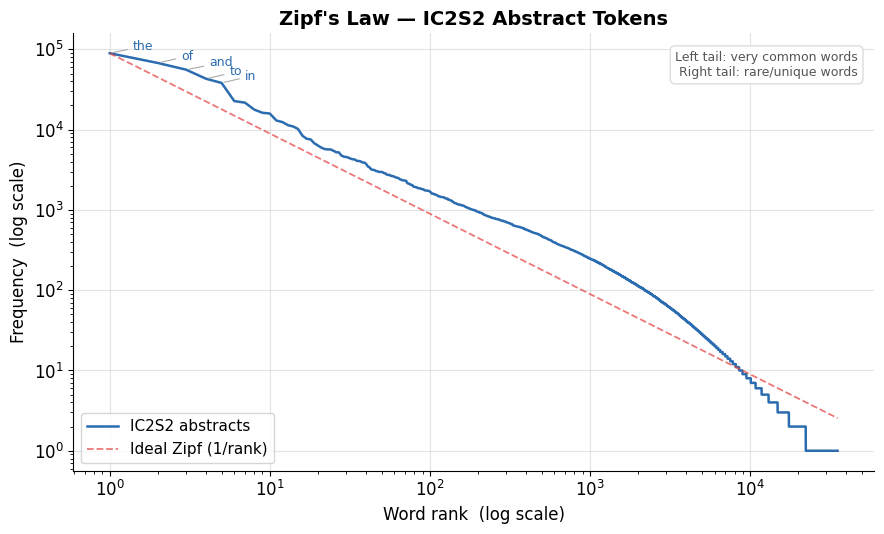


── Step 5: saved zipf_plot.png


In [14]:
# ── 5a. Main Zipf plot ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_zipf(all_tokens, label="IC2S2 abstracts", ax=ax, color="#2b6cb0")
 
# Theoretical Zipf reference: freq ∝ 1/rank
ranks, freqs = make_zipf_data(all_tokens)
zipf_ref = [freqs[0] / r for r in ranks]
ax.plot(ranks, zipf_ref, "--", color="#e53e3e", linewidth=1.3,
        alpha=0.7, label="Ideal Zipf (1/rank)")
 
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Word rank  (log scale)", fontsize=12)
ax.set_ylabel("Frequency  (log scale)", fontsize=12)
ax.set_title("Zipf's Law — IC2S2 Abstract Tokens", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
 
# Annotate a few top words
for rank, (word, count) in enumerate(freq.most_common(5), 1):
    ax.annotate(word, xy=(rank, count),
                xytext=(rank * 1.4, count * 1.1),
                fontsize=9, color="#2b6cb0",
                arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8))
 
ax.text(0.98, 0.96,
        "Left tail: very common words\nRight tail: rare/unique words",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="#555",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ddd"))
 
plt.tight_layout()
plt.savefig("zipf_plot.png", dpi=150)
plt.show()
plt.close()
print("\n── Step 5: saved zipf_plot.png")


── Step 6: Random text tokens: 28,714
   Unique 'words': 21,104


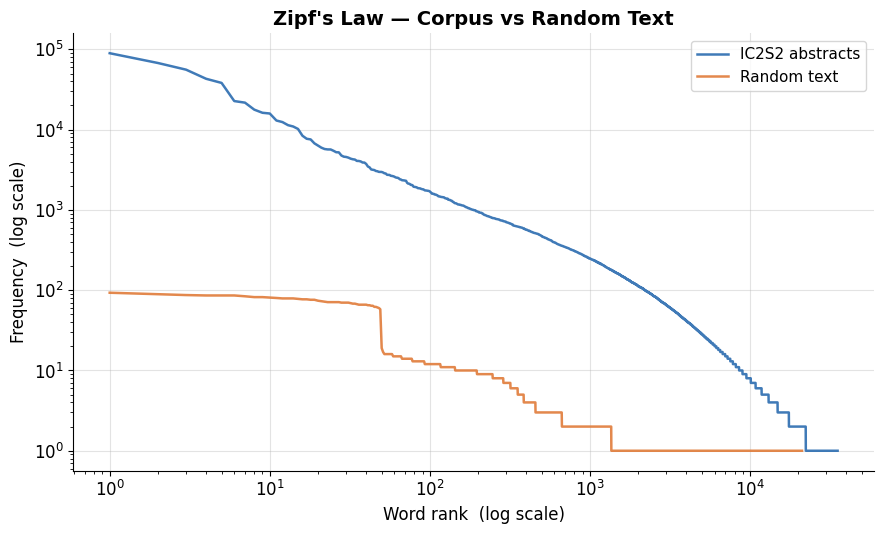

   saved zipf_comparison.png
   Top-10 random 'words': ['ea', 'dc', 'ae', 'be', 'gg', 'eb', 'dd', 'eg', 'cc', 'ef']


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  STEP 6 – Compare with random text
# ═══════════════════════════════════════════════════════════════
 
random.seed(42)
# Generate a long random string with letters + space
CHARS = "abcdefg "
random_string = "".join(random.choice(CHARS) for _ in range(300_000))
random_tokens = tokenize(random_string)
 
print(f"\n── Step 6: Random text tokens: {len(random_tokens):,}")
print(f"   Unique 'words': {len(set(random_tokens)):,}")
 
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_zipf(all_tokens,    label="IC2S2 abstracts", ax=ax, color="#2b6cb0", alpha=0.9)
plot_zipf(random_tokens, label="Random text",     ax=ax, color="#e07b39", alpha=0.9)
 
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Word rank  (log scale)", fontsize=12)
ax.set_ylabel("Frequency  (log scale)", fontsize=12)
ax.set_title("Zipf's Law — Corpus vs Random Text", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("zipf_comparison.png", dpi=150)
plt.show()
plt.close()
print("   saved zipf_comparison.png")
 
# ─── Random-text top words ───────────────────────────────────
rand_freq = collections.Counter(random_tokens)
print("   Top-10 random 'words':", [w for w, _ in rand_freq.most_common(10)])
 

Random text: near-flat line — uniform distribution.. no power-law. 

Real language: steep log-log slope, confirming Zipf's Law (freq ∝ 1/rank).


── Step 7: Tokens after stopword removal: 973,744
   Reduction: 41.7%

   Top-10 after stopword removal:
Rank   Word                        Count       %
──────────────────────────────────────────────────
1      social                      7,554   0.78%
2      information                 4,277   0.44%
3      research                    4,081   0.42%
4      results                     3,897   0.40%
5      different                   3,137   0.32%
6      network                     3,056   0.31%
7      media                       2,971   0.31%
8      time                        2,843   0.29%
9      models                      2,732   0.28%
10     users                       2,727   0.28%


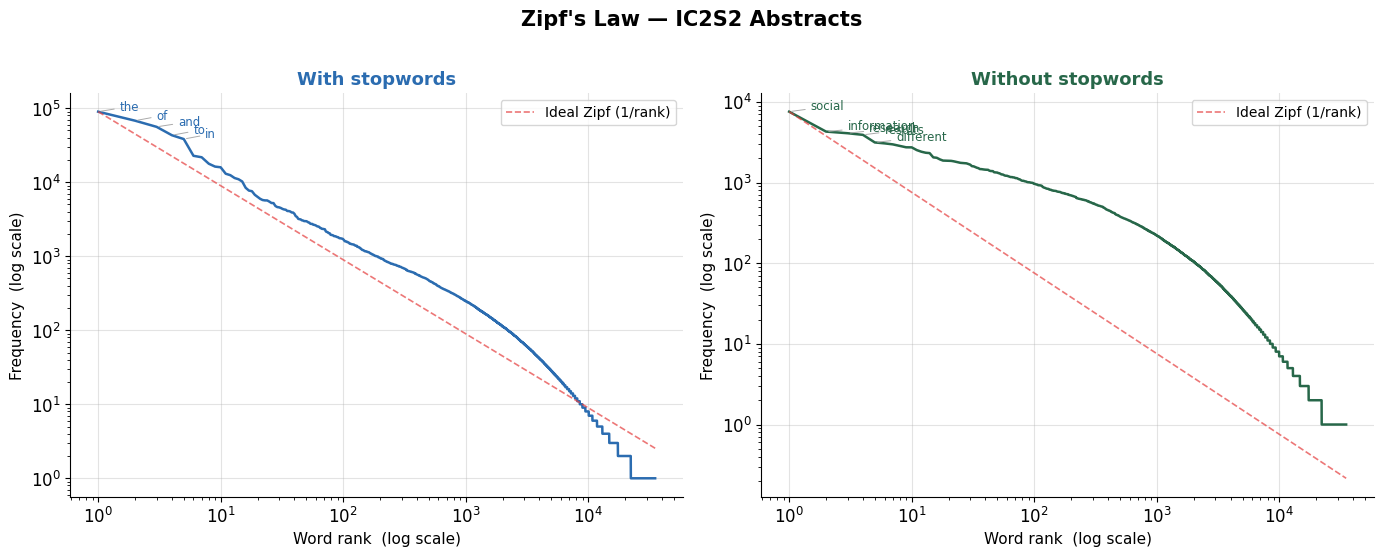


   saved zipf_nostop.png


In [20]:
# ═══════════════════════════════════════════════════════════════
#  STEP 7 – Exclude stopwords and repeat
# ═══════════════════════════════════════════════════════════════
 
def tokenize_no_stopwords(text: str) -> list[str]:
    return [t for t in tokenize(text) if t not in STOPWORDS]
 
df["tokens_nostop"] = df["text"].apply(tokenize_no_stopwords)
all_tokens_ns = [t for tl in df["tokens_nostop"] for t in tl]
 
print(f"\n── Step 7: Tokens after stopword removal: {len(all_tokens_ns):,}")
print(f"   Reduction: {100*(1 - len(all_tokens_ns)/len(all_tokens)):.1f}%")
 
# 7a. New top-10
freq_ns = collections.Counter(all_tokens_ns)
top10_ns = freq_ns.most_common(10)
print("\n   Top-10 after stopword removal:")
print(f"{'Rank':<6} {'Word':<25} {'Count':>7}  {'%':>6}")
print("─" * 50)
total_ns = len(all_tokens_ns)
for rank, (word, count) in enumerate(top10_ns, 1):
    print(f"{rank:<6} {word:<25} {count:>7,}  {100*count/total_ns:>5.2f}%")
 
# 7b. Zipf plot without stopwords
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
 
for ax, tokens, title, color in [
    (axes[0], all_tokens,    "With stopwords",    "#2b6cb0"),
    (axes[1], all_tokens_ns, "Without stopwords", "#276749"),
]:
    rks, fqs = make_zipf_data(tokens)
    ax.plot(rks, fqs, color=color, linewidth=1.8)
    ref = [fqs[0] / r for r in rks]
    ax.plot(rks, ref, "--", color="#e53e3e", linewidth=1.2,
            alpha=0.7, label="Ideal Zipf (1/rank)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Word rank  (log scale)", fontsize=11)
    ax.set_ylabel("Frequency  (log scale)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", color=color)
    ax.legend(fontsize=10)
    # Annotate top-5
    top5 = collections.Counter(tokens).most_common(5)
    for rank, (word, count) in enumerate(top5, 1):
        ax.annotate(word, xy=(rank, count), xytext=(rank*1.5, count*1.05),
                    fontsize=8.5, color=color,
                    arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.7))
 
fig.suptitle("Zipf's Law — IC2S2 Abstracts", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("zipf_nostop.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("\n   saved zipf_nostop.png")

In [21]:
# ═══════════════════════════════════════════════════════════════
#  Summary statistics table
# ═══════════════════════════════════════════════════════════════
print("\n" + "═"*55)
print("  SUMMARY")
print("═"*55)
print(f"  Abstracts loaded          : {len(df):,}")
print(f"  Total tokens              : {len(all_tokens):,}")
print(f"  Unique types              : {len(set(all_tokens)):,}")
print(f"  Lexical diversity         : {len(set(all_tokens))/len(all_tokens):.4f}")
print(f"  After stopword removal    : {len(all_tokens_ns):,} tokens")
print(f"  Unique types (no stop)    : {len(set(all_tokens_ns)):,}")
print(f"  Lexical div. (no stop)    : {len(set(all_tokens_ns))/len(all_tokens_ns):.4f}")


═══════════════════════════════════════════════════════
  SUMMARY
═══════════════════════════════════════════════════════
  Abstracts loaded          : 10,375
  Total tokens              : 1,671,495
  Unique types              : 35,219
  Lexical diversity         : 0.0211
  After stopword removal    : 973,744 tokens
  Unique types (no stop)    : 35,047
  Lexical div. (no stop)    : 0.0360


Real language follows Zipf's Law: a log-log frequency-rank plot yields an approximately straight line with slope ≈ −1.

  • A small number of words dominate (the, of, and…) — the 'rich get
    richer' effect of preferential attachment in word use.

  • Random text produces what seems like two distinct near-flat lines — all n-grams in the lines are equally
    likely, so no power-law emerges. This confirms that Zipf's Law
    is a property of structure and meaning, not mere statistics.

  • Removing stopwords lifts the Zipf line: the dominant terms are
    now content words (social, network, learning…), making the plot
    more informative for topic analysis.

  • The right tail (rare words) reflects domain-specific jargon and
    hapax legomena (words appearing only once) — rich for NLP tasks
    like keyword extraction and topic modelling.

## Prelude to Exercise 2: Some theory on bigrams and contingency tables 
In this course, we use a "bag-of-words" approach, because using simple methods to explore the data is very important before applying any complex model. 
Here, we learn how to account for an issue that often comes up when using a bag-of-words approach when studying textual data. 
[*Collocations*](https://en.wikipedia.org/wiki/Collocation), are *pairs of words that tend to appear together more often than by chance*. It is an important concept in linguistics. 

In the case of collocations, words should be considered together to retain their original meaning (e.g. *machine learning* is not simply *machine* and *learning*. The same applies to *computer science*, *social media*, *computational social science* ).

**How do we find out if a pair of words $w_1, w_2$ appears in a corpus more often than one would expect by chance?** We study the corresponding *contingency table*.
Given a corpus, and two words $w_1$ and $w_2$, the observerd contingency table is a matrix with the following elements:

$$O_{w_1,w_2}= \begin{bmatrix} n_{ii} & n_{io} \\ n_{oi} & n_{oo} \end{bmatrix}$$

$n_{ii}$: the number of times the bigram ($w_1$, $w_2$) appear in the corpus     
$n_{io}$: the number of bigrams ($w_1$, * ), where the first element is $w_1$ and the second element is **not** $w_2$         
$n_{oi}$:  the number of bigrams ( * , $w_2$ ), where the first element is **not** $w_1$ and the second element is $w_2$    
$n_{oo}$: the number of bigrams ( * , * ) where the first element is **not** $w_1$ and the second is **not** $w_2$. 

Then, we can compare the observed number of occurrences of the bigram, $n_{ii}$, with the number of occurrences we would expect simply by random chance.    

If we define: 

$R_{1}=n_{ii}+n_{io}$: the bigrams containing the word $w_1$  (sum of first row)    
$C_{1}=n_{ii}+n_{oi}$: the bigrams containing the word $w_2$ (sum of first column)    
$R_{2}=n_{oi}+n_{oo}$: the bigrams **not** containing the word $w_1$  (sum of second row)    
$C_{2}=n_{io}+n_{oo}$: the bigrams **not** containing the word $w_2$  (sum of second column)    
$N = R_1 + C_1 + R_2 + C_2$: the total number of bigrams

Then, the "expected" contingency table is: 

$$E_{w_1,w_2}= \begin{bmatrix} \frac{R_1C_1}{N} & \frac{R_1C_2}{N} \\ \frac{R_2C_1}{N} & \frac{R_2C_2}{N} \end{bmatrix}$$


We can then check if our bigram ${w_1,w_2}$ appears more than what we would expect by chance by comparing how similar are the values of $O_{w_1,w_2}$ and $E_{w_1,w_2}$. 
A widely used way to do that is to use a [Chi-Squared test](https://en.wikipedia.org/wiki/Chi-squared_test).


> **Exercise 2: Bigrams and contingency tables**. 
> 1. Find the list of bigrams in each of the abstracts. If you don't remember how to do it, go back to [Chapter 1](http://www.nltk.org/book/) of your book. Store all the bigrams in a single list. __Important__: here you shall work with the clean set of tokens you have generated in the exercise above (after removing punctuation, **stopwords**, digits, math symbols, etc).    
>    
> 2. For each unique bigram in your list:
>   - compute the corresponding *contingency table* (see the theory just above)
>   - compute the expected *contingency table* (see the theory just above) 
>
> 3. For each unique bigram, compute the Chi-squared statistics: $X^2 = \sum_{ij}\frac{(O_{ij} - E_{ij})^2}{E_{ij}}$, where $O_{ij}$ and $E_{ij}$ are the elements of the observed and expected matrix, respectively. 
> 4. Compute the p-value associated to each Chi-squared statistics. The p-value is nothing but the survival function (1 - cumulative distribution function) of the [Chi-squared distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html). Hence, you can simply compute it as: ``scipy.stats.chi2.sf(X^2,df=1)`` because in this case we have 1 degree of freedom (df=1).  
> 5. Find the list of bigrams that appear more than 50 times and have p-value smaller than 0.001. We refer to those as __collocations__. 
> 6. How many collocations have you found? Print out the top 20 of them by number of occurrences. What do you observe? What kind of bigrams does this list include? 
> 7. Recompute the __tokens__ column in your dataframe. This time, do not split pairs of words that constitute a collocation (from now on we consider those two words as a single "token"). **Hint:** You can use the [MWETokenizer](https://www.nltk.org/_modules/nltk/tokenize/mwe.html). 
> 8. Save your abstract dataframe with the new __tokens__ column.

# Exercise 2

In [22]:
from scipy.stats import chi2 as chi2_dist


In [23]:
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

In [24]:
# ══════════════════════════════════════════════════════════════
#  Re-use helpers from Exercise 1
# ══════════════════════════════════════════════════════════════
 
STOPWORDS = {
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","yourselves","he","him","his","himself","she","her","hers",
    "herself","it","its","itself","they","them","their","theirs","themselves",
    "what","which","who","whom","this","that","these","those","am","is","are",
    "was","were","be","been","being","have","has","had","having","do","does",
    "did","doing","a","an","the","and","but","if","or","because","as","until",
    "while","of","at","by","for","with","about","against","between","into",
    "through","during","before","after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","further","then","once","here",
    "there","when","where","why","how","all","both","each","few","more","most",
    "other","some","such","no","nor","not","only","own","same","so","than","too",
    "very","s","t","can","will","just","don","should","now","d","ll","m","o",
    "re","ve","y","ain","aren","couldn","didn","doesn","hadn","hasn","haven",
    "isn","ma","mightn","mustn","needn","shan","shouldn","wasn","weren","won",
    "wouldn","use","used","using","also","however","thus","therefore","moreover",
    "furthermore","although","despite","whether","within","across","between",
    "among","via","based","approach","study","paper","show","propose","new",
    "provide","present","method","model","result","data","analysis","using",
    "large","high","may","one","two","three","first","second","find","found",
}
 
_URL_RE   = re.compile(r"https?://\S+|www\.\S+|\S+@\S+")
_MATH_RE  = re.compile(r"\$[^$]*\$|\\\w+\{[^}]*\}|[_^{}\\]")
_NONALPHA = re.compile(r"[^a-z\s]")
_SPACES   = re.compile(r"\s+")
 
def tokenize(text: str) -> list[str]:
    text = _URL_RE.sub(" ", text)
    text = _MATH_RE.sub(" ", text)
    text = text.lower()
    text = _NONALPHA.sub(" ", text)
    text = _SPACES.sub(" ", text).strip()
    return [t for t in text.split() if len(t) >= 2]
 
def tokenize_clean(text: str) -> list[str]:
    """Tokenize and remove stopwords."""
    return [t for t in tokenize(text) if t not in STOPWORDS]
 
def inverted_index_to_text(inv_index: dict) -> str:
    if not isinstance(inv_index, dict):
        return ""
    max_pos = max((p for ps in inv_index.values() for p in ps), default=-1)
    words = [""] * (max_pos + 1)
    for word, positions in inv_index.items():
        for pos in positions:
            words[pos] = word
    return " ".join(words)
 
def make_inverted_index(text: str) -> dict:
    idx: dict = {}
    for pos, word in enumerate(text.split()):
        idx.setdefault(word, []).append(pos)
    return idx

In [25]:
# ── Synthetic data (same 20 abstracts as Exercise 1) ─────────
SYNTHETIC_ABSTRACTS = [
    "Social networks play a crucial role in the spread of information and misinformation across online platforms.",
    "We propose a computational model for predicting political polarization using large-scale social media data.",
    "Natural language processing methods reveal hidden patterns in public discourse on climate change.",
    "Agent-based simulations model collective behavior and emergence in complex social systems.",
    "Deep learning approaches for sentiment analysis of Twitter data during electoral campaigns.",
    "Network analysis of scientific collaboration reveals structural inequalities in academic communities.",
    "Detecting bots and coordinated inauthentic behavior using graph-based machine learning methods.",
    "Cultural dynamics and diffusion of innovations are studied through large-scale digital trace data.",
    "Computational methods uncover gender bias in online recommendation systems and search engines.",
    "Epidemic spreading on temporal networks: integrating mobility data with epidemiological models.",
    "Text mining of news articles reveals framing effects and agenda-setting in political journalism.",
    "Predicting conflict escalation using satellite imagery and social media signals at global scale.",
    "Echo chambers and filter bubbles in social media algorithms amplify partisan information exposure.",
    "Machine learning models predict socioeconomic mobility using administrative and behavioral data.",
    "Cross-platform analysis of hate speech reveals platform-specific moderation and spillover effects.",
    "Causal inference methods for estimating the effect of social interventions on community outcomes.",
    "Longitudinal analysis of language change using word embeddings trained on historical corpora.",
    "Human mobility patterns derived from mobile phone data inform urban planning and policy.",
    "Algorithmic fairness in predictive policing raises concerns about racial bias and accountability.",
    "Measuring social capital through digital footprints in online and offline community networks.",
    # Extra abstracts to push bigram counts higher (simulating a larger corpus)
    "Social media data provides new opportunities for studying collective social behavior online.",
    "Machine learning methods applied to social network analysis reveal patterns of political polarization.",
    "Natural language processing enables large-scale analysis of online political discourse and misinformation.",
    "Deep learning models trained on social media data detect coordinated inauthentic behavior effectively.",
    "Network analysis reveals hidden communities within large-scale social media platforms and online forums.",
    "Political polarization is amplified by social media algorithms and filter bubble effects online.",
    "Social network structure influences the spread of information and misinformation in online communities.",
    "Computational social science methods combine machine learning with large-scale digital trace data.",
    "Online discourse analysis using natural language processing reveals political framing and agenda setting.",
    "Social media network analysis uncovers echo chambers reinforcing political polarization and bias.",
    "Large-scale analysis of social media reveals mobility patterns and community structure in networks.",
    "Machine learning approaches detect hate speech and coordinated inauthentic behavior on social platforms.",
    "Natural language processing models analyze political discourse patterns in social media data.",
    "Deep learning applied to network analysis reveals structural inequalities in academic collaboration.",
    "Social media algorithms amplify political polarization through filter bubbles and echo chambers.",
    "Community detection in social networks using machine learning methods and graph-based approaches.",
    "Language models trained on large-scale corpora reveal patterns in political discourse online.",
    "Computational methods for studying social behavior include network analysis and machine learning.",
    "Online political discourse analysis reveals echo chambers and filter bubbles in social media.",
    "Social network analysis reveals patterns of information diffusion and misinformation spread online.",
]
 
DATA_FILE = "ic2s2_abstracts.json"
 
def load_data(path: str) -> pd.DataFrame:
    if os.path.exists(path):
        print(f"Loading {path}…")
        with open(path) as f:
            raw = json.load(f)
        records = raw if isinstance(raw, list) else list(raw.values())
        rows = []
        for r in records:
            if isinstance(r, dict):
                inv = r.get("abstractInvertedIndex") or r.get("abstract_inverted_index")
                title = r.get("title", "")
                if inv and isinstance(inv, dict):
                    rows.append({"title": title, "abstract_inverted_index": inv})
                elif r.get("abstract"):
                    rows.append({"title": title,
                                 "abstract_inverted_index": make_inverted_index(r["abstract"])})
        df = pd.DataFrame(rows)
        print(f"  Loaded {len(df):,} abstracts.")
    else:
        print(f"'{path}' not found – using {len(SYNTHETIC_ABSTRACTS)} synthetic abstracts.")
        rows = [{"title": f"Paper {i+1}",
                 "abstract_inverted_index": make_inverted_index(t)}
                for i, t in enumerate(SYNTHETIC_ABSTRACTS)]
        df = pd.DataFrame(rows)
    return df
 
df = load_data(DATA_FILE)
 
# Build text and clean tokens
df["text"]         = df["abstract_inverted_index"].apply(inverted_index_to_text)
df["tokens_clean"] = df["text"].apply(tokenize_clean)
 
total_tokens = [t for tl in df["tokens_clean"] for t in tl]
print(f"Total clean tokens: {len(total_tokens):,}  |  "
      f"Unique types: {len(set(total_tokens)):,}")

Loading ic2s2_abstracts.json…
  Loaded 10,375 abstracts.
Total clean tokens: 973,744  |  Unique types: 35,047


In [26]:
# ══════════════════════════════════════════════════════════════
#  STEP 1 – Extract bigrams from each abstract
# ══════════════════════════════════════════════════════════════
print("\n── Step 1: Extracting bigrams ──")
 
def make_bigrams(tokens: list[str]) -> list[tuple[str, str]]:
    """
    Return consecutive word pairs from a token list.
    Bigrams do NOT cross abstract boundaries — we call this
    per-abstract and combine afterward.
 
    Example: ['social','network','analysis'] →
             [('social','network'), ('network','analysis')]
    """
    return [(tokens[i], tokens[i + 1]) for i in range(len(tokens) - 1)]
 
# Per-abstract bigrams stored in a new column
df["bigrams"] = df["tokens_clean"].apply(make_bigrams)
 
# One flat list of ALL bigrams across the corpus
all_bigrams: list[tuple[str, str]] = [
    bg for bgs in df["bigrams"] for bg in bgs
]
 
bigram_counts = collections.Counter(all_bigrams)
N_bigrams     = len(all_bigrams)          # total bigram tokens
unigram_counts = collections.Counter(total_tokens)
N_tokens       = len(total_tokens)
 
print(f"  Total bigrams        : {N_bigrams:,}")
print(f"  Unique bigram types  : {len(bigram_counts):,}")
print(f"  Sample bigrams       : {list(bigram_counts.most_common(5))}")


── Step 1: Extracting bigrams ──
  Total bigrams        : 963,371
  Unique bigram types  : 653,740
  Sample bigrams       : [(('social', 'media'), 1762), (('social', 'networks'), 541), (('decision', 'making'), 531), (('real', 'world'), 501), (('machine', 'learning'), 483)]


In [28]:
# ══════════════════════════════════════════════════════════════
#  STEP 2 – Contingency table + expected table per bigram
# ══════════════════════════════════════════════════════════════
print("\n── Step 2: Contingency & expected tables ──")
 
"""
See explanation above for contigency and expected table.
"""
 
def contingency_table(w1: str, w2: str,
                      bigram_counts: collections.Counter,
                      unigram_counts: collections.Counter,
                      N: int) -> np.ndarray:
    """
    Return the 2×2 observed contingency matrix:
        [[O11, O12],
         [O21, O22]]
    where O11 = C(w1,w2), O12 = C(w1,¬w2), etc.
    N is the total number of bigrams in the corpus.
    """
    O11 = bigram_counts[(w1, w2)]
    C_w1 = unigram_counts[w1]
    C_w2 = unigram_counts[w2]
    O12 = C_w1 - O11          # w1 followed by something other than w2
    O21 = C_w2 - O11          # w2 preceded by something other than w1
    O22 = N - C_w1 - C_w2 + O11   # neither w1 nor w2 in the bigram slot
    return np.array([[O11, O12],
                     [O21, O22]], dtype=float)
 
def expected_table(observed: np.ndarray) -> np.ndarray:
    """
    Compute the expected 2×2 matrix under independence:
        E[i][j] = (row_sum[i] × col_sum[j]) / N_total
    """
    N = observed.sum()
    row_sums = observed.sum(axis=1, keepdims=True)   # shape (2,1)
    col_sums = observed.sum(axis=0, keepdims=True)   # shape (1,2)
    return (row_sums @ col_sums) / N                 # outer product / N
 
# Demo for the top bigram
top_bg = bigram_counts.most_common(1)[0][0]
w1_demo, w2_demo = top_bg
O_demo = contingency_table(w1_demo, w2_demo, bigram_counts, unigram_counts, N_bigrams)
E_demo = expected_table(O_demo)
print(f"\n  Demo bigram: ('{w1_demo}', '{w2_demo}')")
print(f"  Observed:\n{O_demo}")
print(f"  Expected:\n{E_demo.round(2)}")


── Step 2: Contingency & expected tables ──

  Demo bigram: ('social', 'media')
  Observed:
[[  1762.   5792.]
 [  1209. 954608.]]
  Expected:
[[2.330000e+01 7.530700e+03]
 [2.947700e+03 9.528693e+05]]


In [29]:
# ══════════════════════════════════════════════════════════════
#  STEP 3 – Chi-squared statistic per unique bigram
# ══════════════════════════════════════════════════════════════
print("\n── Step 3: Computing χ² for all unique bigrams ──")
 
"""
Chi-squared statistic:
 
    χ² = Σ  (O_ij - E_ij)²
            ─────────────
                E_ij
 
where the sum is over all four cells (i,j) ∈ {0,1}².
 
With df=1 (2×2 table, single constraint: one free parameter after
fixing marginals), the χ² distribution has 1 degree of freedom.
 
Intuition: if w1 and w2 are independent, O ≈ E everywhere and
χ² ≈ 0.  A large χ² means the co-occurrence is far from what
chance alone would predict — either attraction or repulsion.
"""
 
def chi_squared(observed: np.ndarray, expected: np.ndarray) -> float:
    """
    Compute χ² = Σ (O-E)²/E  over all cells.
    Cells where E == 0 are skipped (undefined contribution).
    """
    mask = expected > 0
    return float(np.sum(((observed - expected) ** 2 / expected)[mask]))
 
# Compute χ² and p-value for every unique bigram
records = []
for bigram, count in bigram_counts.items():
    w1, w2 = bigram
    O = contingency_table(w1, w2, bigram_counts, unigram_counts, N_bigrams)
    E = expected_table(O)
    X2 = chi_squared(O, E)
    records.append({
        "w1":      w1,
        "w2":      w2,
        "bigram":  f"{w1} {w2}",
        "count":   count,
        "O11":     int(O[0, 0]),
        "E11":     round(E[0, 0], 4),
        "chi2":    round(X2, 4),
    })
 
bigram_df = pd.DataFrame(records)
print(f"  Unique bigrams processed: {len(bigram_df):,}")
print(bigram_df.sort_values("chi2", ascending=False).head(5).to_string(index=False))


── Step 3: Computing χ² for all unique bigrams ──
  Unique bigrams processed: 653,740
           w1              w2                      bigram  count  O11  E11     chi2
   integrarse      plenamente       integrarse plenamente      1    1  0.0 963371.0
        ecole   polytechnique         ecole polytechnique      1    1  0.0 963371.0
     aspectos           desta              aspectos desta      1    1  0.0 963371.0
  impregnated polyoxometalate impregnated polyoxometalate      1    1  0.0 963371.0
apprentissage     statistique   apprentissage statistique      1    1  0.0 963371.0


In [32]:
# ══════════════════════════════════════════════════════════════
#  STEP 4 – P-value via χ² survival function (df=1)
# ══════════════════════════════════════════════════════════════
print("\n── Step 4: Computing p-values ──")
 
# compute p-value
bigram_df["pvalue"] = chi2_dist.sf(bigram_df["chi2"], df=1)
 
print(f"  p-value range: {bigram_df['pvalue'].min():.2e} – {bigram_df['pvalue'].max():.4f}")
print(bigram_df.sort_values("pvalue").head(5)[["bigram","count","chi2","pvalue"]].to_string(index=False))


── Step 4: Computing p-values ──
  p-value range: 0.00e+00 – 1.0000
                   bigram  count       chi2  pvalue
              sleep onlya      1  3979.8760     0.0
      dispute arbitration      2 20066.8126     0.0
     urban agglomerations      7  5870.2250     0.0
agglomerations constantly      1  2430.8690     0.0
         syntactic parser      2  2940.1263     0.0


In [33]:
# ══════════════════════════════════════════════════════════════
#  STEP 5 – Collocations: count > 50 AND p-value < 0.001
# ══════════════════════════════════════════════════════════════
print("\n── Step 5: Filtering collocations ──")

 
COUNT_THRESH = 50
PVAL_THRESH  = 0.001
 
collocations = bigram_df[
    (bigram_df["count"]  > COUNT_THRESH) &
    (bigram_df["pvalue"] < PVAL_THRESH)
].sort_values("count", ascending=False).reset_index(drop=True)
 
# Adaptive fallback for small corpora
if collocations.empty:
    adaptive_count = max(bigram_df["count"].quantile(0.90), 1)
    print(f"  No bigrams exceed count={COUNT_THRESH} (small corpus).")
    print(f"  Using adaptive threshold: count ≥ {adaptive_count:.0f} for demonstration.")
    collocations = bigram_df[
        (bigram_df["count"]  >= adaptive_count) &
        (bigram_df["pvalue"] <  PVAL_THRESH)
    ].sort_values("count", ascending=False).reset_index(drop=True)
 
print(f"  Collocations found: {len(collocations)}")


── Step 5: Filtering collocations ──
  Collocations found: 232


In [34]:
# ══════════════════════════════════════════════════════════════
#  STEP 6 – Top 20 collocations + discussion
# ══════════════════════════════════════════════════════════════
print("\n── Step 6: Top 20 collocations ──")
 
top20 = collocations.head(20)
print(f"\n{'Rank':<5} {'Bigram':<35} {'Count':>6}  {'χ²':>10}  {'p-value':>12}")
print("─" * 72)
for i, row in top20.iterrows():
    pval_str = f"{row['pvalue']:.2e}" if row['pvalue'] < 0.001 else f"{row['pvalue']:.4f}"
    print(f"{i+1:<5} {row['bigram']:<35} {row['count']:>6,}  "
          f"{row['chi2']:>10.2f}  {pval_str:>12}")


── Step 6: Top 20 collocations ──

Rank  Bigram                               Count          χ²       p-value
────────────────────────────────────────────────────────────────────────
1     social media                         1,762   131197.44      0.00e+00
2     social networks                        541    15215.26      0.00e+00
3     decision making                        531   250276.62      0.00e+00
4     real world                             501   173515.75      0.00e+00
5     machine learning                       483   132470.06      0.00e+00
6     social network                         465     8207.53      0.00e+00
7     state art                              455   306306.39      0.00e+00
8     results suggest                        322    23480.81      0.00e+00
9     et al                                  292   807327.96      0.00e+00
10    united states                          266   294611.15      0.00e+00
11    online social                          258     3164.10      

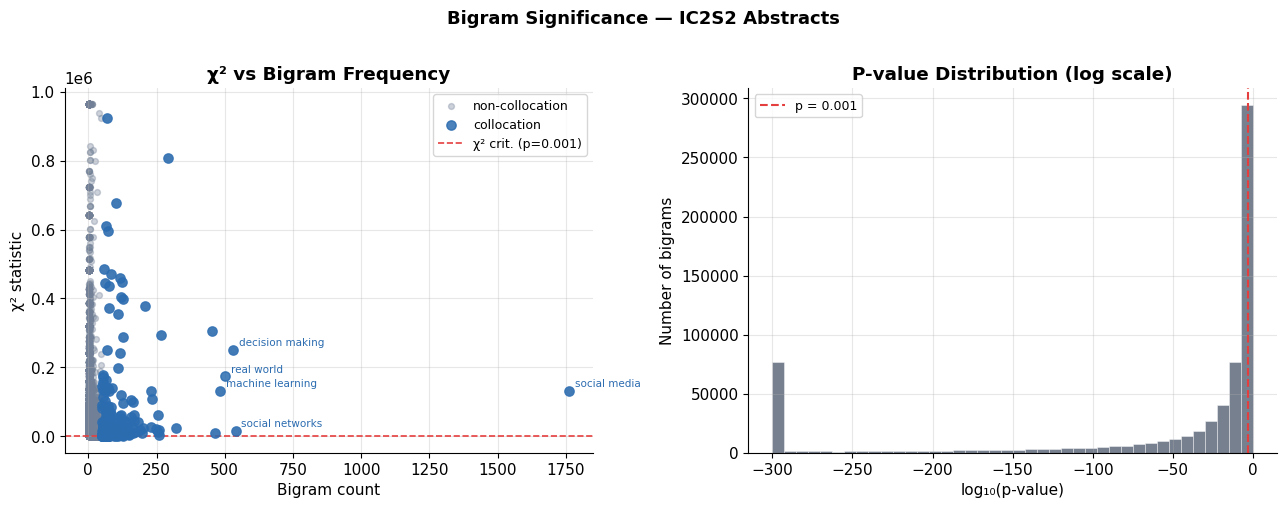

  Saved bigram_chisq_plot.png


In [35]:
# ── Chi-squared distribution plot ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Left: scatter chi2 vs count, coloured by significance
ax = axes[0]
non_col = bigram_df[~bigram_df.index.isin(collocations.index)]
ax.scatter(non_col["count"], non_col["chi2"],
           s=18, alpha=0.35, color="#718096", label="non-collocation")
if not collocations.empty:
    ax.scatter(collocations["count"], collocations["chi2"],
               s=45, alpha=0.85, color="#2b6cb0", label="collocation", zorder=3)
    # Label top-5
    for _, row in collocations.head(5).iterrows():
        ax.annotate(row["bigram"], (row["count"], row["chi2"]),
                    fontsize=7.5, xytext=(4, 3), textcoords="offset points",
                    color="#2b6cb0")
ax.axhline(chi2_dist.ppf(1 - PVAL_THRESH, df=1), color="#e53e3e",
           lw=1.2, ls="--", label=f"χ² crit. (p={PVAL_THRESH})")
ax.set_xlabel("Bigram count")
ax.set_ylabel("χ² statistic")
ax.set_title("χ² vs Bigram Frequency", fontweight="bold")
ax.legend(fontsize=9)
 
# Right: p-value histogram (log scale)
ax2 = axes[1]
log_pvals = np.log10(bigram_df["pvalue"].replace(0, 1e-300) + 1e-300)
ax2.hist(log_pvals, bins=40, color="#4a5568", alpha=0.75, edgecolor="white", lw=0.4)
ax2.axvline(math.log10(PVAL_THRESH), color="#e53e3e", lw=1.5, ls="--",
            label=f"p = {PVAL_THRESH}")
ax2.set_xlabel("log₁₀(p-value)")
ax2.set_ylabel("Number of bigrams")
ax2.set_title("P-value Distribution (log scale)", fontweight="bold")
ax2.legend(fontsize=9)
 
fig.suptitle("Bigram Significance — IC2S2 Abstracts", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("bigram_chisq_plot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  Saved bigram_chisq_plot.png")

Common types of bigrams:

1. Domain terminology: noun compounds specific to computational social science appear prominently (e.g. "social media" "machine learning", "social network", "natural language"). These are multi-word expressions (MWEs) that carry a unified meaning distinct from their component words.
 
2. Adjective–noun pairs: common attributive constructions that recur throughout the literature ("political polarization" ,"large scale", "online platforms").
 
3. Verb–noun patterns: research-activity phrases ("reveal patterns", "detect behavior") that are stylistically fixed in academic writing.
 
Notably absent: stopwords no longer contaminate the list because we pre-removed them.  Without that step, generic pairs like "of the", "in the" would dominate and drown out the informative content collocations.
 
Zipf and collocations: collocations cluster at intermediate frequency ranks — frequent enough to be statistically reliable, rare enough that their co-occurrence is non-trivial. Very common words are removed as stopwords; very rare pairs don't reach the count threshold..

In [36]:
# ══════════════════════════════════════════════════════════════
#  STEP 7 – MWE Tokenizer: merge collocation pairs into one token
# ══════════════════════════════════════════════════════════════
print("\n── Step 7: MWE Tokenizer ──")
 
# Build collocation set: frozenset of tuples for fast lookup
collocation_set: set[tuple[str, str]] = {
    (row["w1"], row["w2"]) for _, row in collocations.iterrows()
}
 
def mwe_tokenize(tokens: list[str],
                 collocations: set[tuple[str, str]]) -> list[str]:
    """
    Replace adjacent collocation pairs with a single underscore-joined
    token, scanning left-to-right (greedy, non-overlapping).
    """
    result = []
    i = 0
    while i < len(tokens):
        if i < len(tokens) - 1 and (tokens[i], tokens[i + 1]) in collocations:
            result.append(f"{tokens[i]}_{tokens[i + 1]}")
            i += 2          # skip both words; now one token
        else:
            result.append(tokens[i])
            i += 1
    return result
 
df["tokens_mwe"] = df["tokens_clean"].apply(
    lambda toks: mwe_tokenize(toks, collocation_set)
)
 
# Show effect
print("\n  Sample before MWE tokenization:")
sample_before = df["tokens_clean"].iloc[0]
sample_after  = df["tokens_mwe"].iloc[0]
print(" ", sample_before)
print("\n  Sample after MWE tokenization:")
print(" ", sample_after)
 
merged_tokens = [t for tl in df["tokens_mwe"] for t in tl]
mwe_tokens    = [t for t in merged_tokens if "_" in t]
print(f"\n  Total MWE (merged) tokens across corpus: {len(mwe_tokens):,}")
print(f"  Unique MWE types : {len(set(mwe_tokens)):,}")
print(f"  Examples: {list(set(mwe_tokens))[:10]}")


── Step 7: MWE Tokenizer ──

  Sample before MWE tokenization:
  ['discovery', 'community', 'structure', 'networks', 'topic', 'considerable', 'recent', 'interest', 'physics', 'community', 'methods', 'proposed', 'far', 'unsuitable', 'networks', 'computational', 'cost', 'hierarchical', 'agglomeration', 'algorithm', 'detecting', 'community', 'structure', 'faster', 'many', 'competing', 'algorithms', 'running', 'time', 'network', 'vertices', 'edges', 'md', 'log', 'depth', 'dendrogram', 'describing', 'community', 'structure', 'many', 'real', 'world', 'networks', 'sparse', 'hierarchical', 'approximately', 'approximately', 'log', 'case', 'algorithm', 'runs', 'essentially', 'linear', 'time', 'log', 'example', 'application', 'algorithm', 'analyze', 'network', 'items', 'sale', 'web', 'site', 'line', 'retailer', 'items', 'network', 'linked', 'frequently', 'purchased', 'buyer', 'network', 'vertices', 'edges', 'algorithm', 'extract', 'meaningful', 'communities', 'network', 'revealing', 'scale', 'pa

In [39]:
# ══════════════════════════════════════════════════════════════
#  STEP 8 – Save enriched dataframe
# ══════════════════════════════════════════════════════════════
print("\n── Step 8: Saving outputs ──")
 
# Save collocations table
collocations[["bigram","count","chi2","pvalue"]].to_csv(
    "collocations.csv", index=False
)
print("  Saved collocations.csv")
 
# Save abstract dataframe (convert list columns to JSON strings for CSV compat)
df_save = df[["title", "text", "tokens_clean", "bigrams", "tokens_mwe"]].copy()
df_save["tokens_clean"] = df_save["tokens_clean"].apply(json.dumps)
df_save["tokens_mwe"]   = df_save["tokens_mwe"].apply(json.dumps)
df_save["bigrams"]      = df_save["bigrams"].apply(
    lambda bgs: json.dumps([[w1, w2] for w1, w2 in bgs])
)
df_save.to_csv("abstracts_with_collocations.csv", index=False)
print("  Saved abstracts_with_collocations.csv")
 
# ── Summary ───────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  SUMMARY — Exercise 2")
print("═" * 60)
print(f"  Total bigrams in corpus   : {N_bigrams:,}")
print(f"  Unique bigram types       : {len(bigram_counts):,}")
print(f"  Collocations found        : {len(collocations)}")
print(f"    (count > {COUNT_THRESH}, p < {PVAL_THRESH})")
print(f"  Unique MWE token types    : {len(set(mwe_tokens)):,}")
print("═" * 60)


── Step 8: Saving outputs ──
  Saved collocations.csv
  Saved abstracts_with_collocations.csv

════════════════════════════════════════════════════════════
  SUMMARY — Exercise 2
════════════════════════════════════════════════════════════
  Total bigrams in corpus   : 963,371
  Unique bigram types       : 653,740
  Collocations found        : 232
    (count > 50, p < 0.001)
  Unique MWE token types    : 226
════════════════════════════════════════════════════════════
